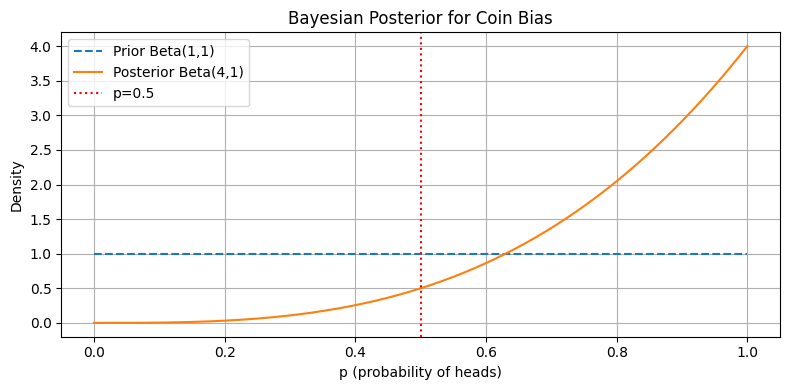

Posterior mean: 0.8000
P(p > 0.5 | data): 0.9386


In [5]:
import jax.numpy as jnp
from jax import jit
import matplotlib.pyplot as plt
from scipy.stats import beta  # for comparison and plotting only
from jax.scipy.special import gammaln

# Define observed data
n = 3           # number of trials
k = 3           # number of heads

# Prior parameters: Beta(1, 1) (uniform)
alpha_prior = 1
beta_prior = 1

# Posterior parameters (conjugate update)
alpha_post = alpha_prior + k
beta_post = beta_prior + (n - k)

# Grid of p values
p_vals = jnp.linspace(0, 1, 500)

# Posterior PDF: Beta(alpha_post, beta_post)
@jit
def beta_pdf(p, a, b):
    norm_const = jnp.exp(gammaln(a + b) - gammaln(a) - gammaln(b))
    return norm_const * p**(a - 1) * (1 - p)**(b - 1)

posterior_pdf = beta_pdf(p_vals, alpha_post, beta_post)

# Posterior mean
posterior_mean = alpha_post / (alpha_post + beta_post)

# Compute probability that p > 0.5
@jit
def p_greater_than_0_5(alpha, beta):
    # Integral of Beta(alpha, beta) from 0.5 to 1
    p_grid = jnp.linspace(0.5, 1.0, 1000)
    pdf_vals = beta_pdf(p_grid, alpha, beta)
    dx = p_grid[1] - p_grid[0]
    return jnp.sum(pdf_vals * dx)

p_gt_0_5 = p_greater_than_0_5(alpha_post, beta_post)

# Plot prior and posterior (optional)
plt.figure(figsize=(8, 4))
plt.plot(p_vals, beta.pdf(p_vals, alpha_prior, beta_prior), '--', label='Prior Beta(1,1)')
plt.plot(p_vals, beta.pdf(p_vals, alpha_post, beta_post), label=f'Posterior Beta({alpha_post},{beta_post})')
plt.axvline(0.5, color='red', linestyle=':', label='p=0.5')
plt.title("Bayesian Posterior for Coin Bias")
plt.xlabel("p (probability of heads)")
plt.ylabel("Density")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# Print results
print(f"Posterior mean: {posterior_mean:.4f}")
print(f"P(p > 0.5 | data): {p_gt_0_5:.4f}")
